In [1]:
import os
os.environ['KERAS_BACKEND'] = 'torch'

In [61]:
import torch
import keras
import datasets
import keras_hub
import transformers
import numpy as np
import tqdm.notebook as tqdm
import sklearn.model_selection
import matplotlib.pyplot as plt
import sklearn.metrics

from collections.abc import Callable

In [3]:
train = datasets.load_dataset('./ag_news', split='train')
test  = datasets.load_dataset('./ag_news', split='test')

In [4]:
tokenizer = transformers.AutoTokenizer.from_pretrained('gpt2')

In [5]:
tokenizer.pad_token = tokenizer.eos_token

In [6]:
def get_name(pref: str | None, suf: str, sep: str = '_') -> str | None:
    return pref and pref + sep + suf

In [7]:
train

Dataset({
    features: ['text', 'label'],
    num_rows: 120000
})

In [8]:
train[0]

{'text': "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.",
 'label': 2}

In [136]:
class LSTM(keras.layers.Layer):

    def __init__(self, features: int, return_sequence: bool = False, return_state: bool = False, use_bias: bool = True, **kwargs):
        super().__init__(**kwargs)
        self.features = features
        self.return_sequence = return_sequence
        self.return_state = return_state
        self.use_bias = use_bias
        
    def build(self, input_shape: tuple):
        # self.forget_gate_w = self.add_weight(shape=(self.features + input_shape[-1], self.features,), name='forget_gate_w')
        # self.output_gate_w = self.add_weight(shape=(self.features + input_shape[-1], self.features,), name='output_gate_w')
        # self.input_gate_w = self.add_weight(shape=(self.features + input_shape[-1], self.features,), name='input_gate_w')
        # self.input_value_w = self.add_weight(shape=(self.features + input_shape[-1], self.features,), name='input_value_w')

        self.w = self.add_weight(shape=(self.features + input_shape[-1], self.features * 4), name='w')
        
        if self.use_bias: 
            # self.forget_gate_b = self.add_weight(shape=(self.features,), name='forget_gate_b')
            # self.output_gate_b = self.add_weight(shape=(self.features,), name='output_gate_b')
            # self.input_gate_b = self.add_weight(shape=(self.features,), name='input_gate_b')
            # self.input_value_b = self.add_weight(shape=(self.features,), name='input_value_b')

            self.bias = self.add_weight(shape=(self.features * 4,), name='bias')
        else: 
            # self.forget_gate_b = self.output_gate_b = self.input_gate_b = self.input_value_b = None
            self.bias = None


        self.h_init = self.add_weight(shape=(self.features,), name='h_init')
        self.c_init = self.add_weight(shape=(self.features,), name='c_init')

    def _apply_weights(self, x: keras.KerasTensor, w: keras.KerasTensor, b: keras.KerasTensor | None, activation: Callable | None = None,):
        x_weights = x @ w

        if b is not None:
            x_weights = x_weights + b
            
        if activation is not None: 
            x_weights = activation(x_weights)

        return x_weights 

    def _with_state(self, returns, state):
        
        if self.return_state:
            return (*returns, state)
        return returns
                                                 
    def call(self, x: keras.KerasTensor):
        batch_size = keras.ops.shape(x)[0]
        h = keras.ops.tile(self.h_init, (batch_size, 1))
        c = keras.ops.tile(self.c_init, (batch_size, 1))
        sequence = []
        for t in range(x.shape[1]):
            x_t = keras.ops.concatenate([h, x[:, t]], axis=1)
            # forget_gate = self._apply_weights(x_t, self.forget_gate_w, self.forget_gate_b, keras.activations.sigmoid,)
            # output_gate = self._apply_weights(x_t, self.output_gate_w, self.output_gate_b, keras.activations.sigmoid,)
            # input_gate = self._apply_weights(x_t, self.input_gate_w, self.input_gate_b, keras.activations.sigmoid,)
            # input_value = self._apply_weights(x_t, self.input_value_w, self.input_value_b, keras.activations.tanh,)
            x_fused = self._apply_weights(x_t, self.w, self.bias)
            forget_gate, output_gate, input_gate, input_value = keras.ops.split(x_fused, 4, axis=-1)
            
            forget_gate = keras.activations.sigmoid(forget_gate)
            output_gate = keras.activations.sigmoid(output_gate)
            input_gate = keras.activations.sigmoid(input_gate)
            input_value = keras.activations.tanh(input_value)
            
            c = c * forget_gate

            inp = input_gate * input_value
            c = c + inp
            h = output_gate * keras.activations.tanh(c)
            if self.return_sequence:
                sequence.append(h)
    
        if self.return_sequence:
            sequence = keras.ops.stack(sequence, axis=1)
            return self._with_state((h, sequence), (c, h))
            
        return self._with_state((h,), (c, h))


    def call(self, x: keras.KerasTensor):
        batch_size, seq_len = keras.ops.shape(x)[:2]
        h = keras.ops.tile(self.h_init, (batch_size, 1))
        c = keras.ops.tile(self.c_init, (batch_size, 1))
        sequences = keras.ops.zeros((batch_size, seq_len, self.features))
        
        def body(i, state):
            h, c = state
            x_t = keras.ops.concatenate([h, x[:, i]], axis=1)
            x_fused = self._apply_weights(x_t, self.w, self.bias)
            forget_gate, output_gate, input_gate, input_value = keras.ops.split(x_fused, 4, axis=-1)
            
            forget_gate = keras.activations.sigmoid(forget_gate)
            output_gate = keras.activations.sigmoid(output_gate)
            input_gate = keras.activations.sigmoid(input_gate)
            input_value = keras.activations.tanh(input_value)
            
            c = c * forget_gate

            inp = input_gate * input_value
            c = c + inp
            h = output_gate * keras.activations.tanh(c)

            indices = 
            return h, c
            
        h, c = keras.ops.fori_loop(0, seq_len, body, (h, c))
        return h
            
    def get_config(self, ) -> dict:
        return {
            'features': self.features,
            'return_sequence': self.return_sequence,
            'return_state': self.return_state,
            'use_bias': self.use_bias,
            **super().get_config(),
        }


        

In [145]:
keras.ops.reshape(keras.ops.stack(keras.ops.meshgrid(keras.ops.arange(5), keras.ops.arange(5)) [::-1], axis=-1), (-1, 2))


tensor([[0, 0],
        [0, 1],
        [0, 2],
        [0, 3],
        [0, 4],
        [1, 0],
        [1, 1],
        [1, 2],
        [1, 3],
        [1, 4],
        [2, 0],
        [2, 1],
        [2, 2],
        [2, 3],
        [2, 4],
        [3, 0],
        [3, 1],
        [3, 2],
        [3, 3],
        [3, 4],
        [4, 0],
        [4, 1],
        [4, 2],
        [4, 3],
        [4, 4]], device='cuda:0', dtype=torch.int32)

In [138]:
keras.ops.scatter_update?

Signature: keras.ops.scatter_update(inputs, indices, updates, reduction=None)
Docstring:
Update inputs via updates at scattered (sparse) indices.

At a high level, this operation does `inputs[indices] = updates`.
Assume `inputs` is a tensor of shape `(D0, D1, ..., Dn)`, there are 2 main
usages of `scatter_update`.

1. `indices` is a 2D tensor of shape `(num_updates, n)`, where `num_updates`
    is the number of updates to perform, and `updates` is a 1D tensor of
    shape `(num_updates,)`. For example, if `inputs` is `zeros((4, 4, 4))`,
    and we want to update `inputs[1, 2, 3]` and `inputs[0, 1, 3]` as 1, then
    we can use:

```python
inputs = np.zeros((4, 4, 4))
indices = [[1, 2, 3], [0, 1, 3]]
updates = np.array([1., 1.])
inputs = keras.ops.scatter_update(inputs, indices, updates)
```

2 `indices` is a 2D tensor of shape `(num_updates, k)`, where `num_updates`
    is the number of updates to perform, and `k` (`k < n`) is the size of
    each index in `indices`. `updates` is a `n 

In [14]:
rng = np.random.default_rng()

In [133]:
lstm = LSTM(features=16, use_bias=False, return_sequence=True, return_state=True)

In [134]:
with torch.no_grad():
    print(lstm(rng.random((2, 8, 8,))))

8 (2, 8, 8)
tensor([[ 0.1272, -0.0173,  0.0814, -0.1647, -0.2003, -0.2062, -0.0990,  0.0896,
         -0.0430, -0.1987,  0.1208,  0.0090, -0.0069,  0.1296,  0.0010, -0.0209],
        [ 0.0860, -0.0684,  0.0346, -0.1472, -0.1735, -0.1233, -0.0838,  0.1229,
         -0.0783, -0.0871,  0.0035,  0.0147, -0.0536,  0.0222, -0.0430, -0.0230]],
       device='cuda:0')


In [103]:
def get_model(embedding_size: int, n_classes: int, sequence_length: int, vocab_size: int, n_stacks: int) -> keras.models.Model:
    inputs = x = keras.layers.Input((None,), dtype='int32', name='Input')
    x = keras.layers.Embedding(vocab_size, embedding_size, name='Embedding')(x)
    
    # for i in range(n_stacks):
    #     _, x = LSTM(embedding_size, name=f'LSTM_{i}', return_sequence=True)(x)
        
    # x = keras.layers.Dense(n_classes, name='Prediction')(x[:, -1])
    x = LSTM(embedding_size, name='LSTM')(x)
    x = keras.layers.Dense(n_classes, name='Prediction')(x)
    return keras.models.Model(inputs=inputs, outputs=x)
    

In [31]:
token_train = [tokenizer.encode(text) for text in train['text']]
token_test = [tokenizer.encode(text) for text in test['text']]

In [34]:
lengths = [len(text) for text in token_train]

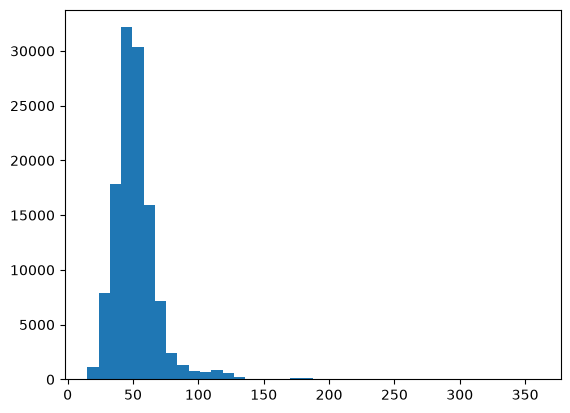

In [39]:
_ = plt.hist(lengths, bins=40)

In [137]:
model = get_model(embedding_size=512, n_classes=4, sequence_length=70, vocab_size=len(tokenizer.get_vocab()), n_stacks=1)

<class 'int'> (83, 83, 512)
<class 'int'> (89, 89, 512)


In [100]:
model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input (InputLayer)              │ (None, 70)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Embedding (Embedding)           │ (None, 70, 512)        │    25,731,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM (LSTM)                     │ (None, 512)            │     2,100,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Prediction (Dense)              │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,833,860 (106.18 MB)

 Trainable params: 27,833,860 (106.18 MB)

 Non-trainable params: 0 (0.00 B)

In [105]:
model.compile(loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True), optimizer=keras.optimizers.Adam(), metrics=['accuracy'])

In [87]:
train_x = keras.utils.pad_sequences(token_train, maxlen=70, padding='post', truncating='post', value=tokenizer.eos_token_id)
test_x = keras.utils.pad_sequences(token_test, maxlen=70, padding='post', truncating='post', value=tokenizer.eos_token_id)

In [88]:
train_label = np.array(train['label'])
test_label = np.array(test['label'])

train_label, test_label

(array([2, 2, 2, ..., 1, 1, 1], shape=(120000,)),
 array([2, 3, 3, ..., 1, 2, 2], shape=(7600,)))

In [89]:
idx = np.arange(len(train_label))
rng.shuffle(idx)

In [90]:
train_label = train_label[idx]
train_x = train_x[idx]

In [106]:
model.fit(train_x, train_label, epochs=5, batch_size=64, validation_data=(test_x, test_label))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 21ms/step - accuracy: 0.6961 - loss: 0.6631 - val_accuracy: 0.9104 - val_loss: 0.2789
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 40s 21ms/step - accuracy: 0.9339 - loss: 0.1995 - val_accuracy: 0.9163 - val_loss: 0.2549
Epoch 3/5
 166/1875 ━━━━━━━━━━━━━━━━━━━━ 35s 21ms/step - accuracy: 0.9595 - loss: 0.1132

KeyboardInterrupt: 

In [107]:
y_pred = model.predict(test_x, batch_size=128)

60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [108]:
y_pred = np.argmax(y_pred, axis=-1)

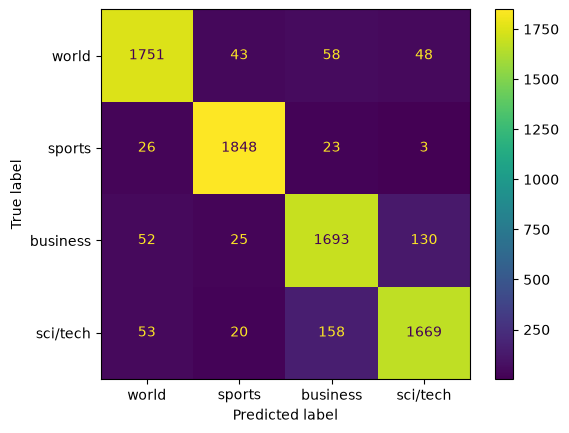

In [109]:
sklearn.metrics.ConfusionMatrixDisplay.from_predictions(test_label, y_pred, display_labels=['world', 'sports', 'business', 'sci/tech'])

In [120]:
train_x = keras.utils.pad_sequences(token_train, maxlen=100, padding='post', truncating='post', value=tokenizer.eos_token_id)
test_x = keras.utils.pad_sequences(token_test, maxlen=100, padding='post', truncating='post', value=tokenizer.eos_token_id)

In [121]:
train_label = np.array(train['label'])
test_label = np.array(test['label'])

train_label, test_label

(array([2, 2, 2, ..., 1, 1, 1], shape=(120000,)),
 array([2, 3, 3, ..., 1, 2, 2], shape=(7600,)))

In [122]:
idx = np.arange(len(train_label))
rng.shuffle(idx)

In [123]:
train_label = train_label[idx]
train_x = train_x[idx]

In [124]:
y_pred = model.predict(test_x, batch_size=128)

60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


In [125]:
y_pred = np.argmax(y_pred, axis=-1)

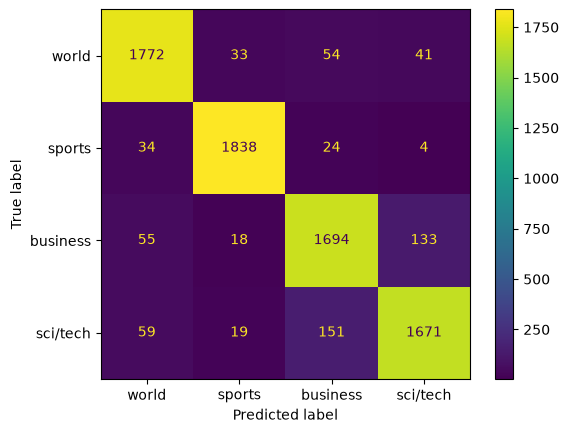

In [126]:
sklearn.metrics.ConfusionMatrixDisplay.from_predictions(test_label, y_pred, display_labels=['world', 'sports', 'business', 'sci/tech'])